## Satellite Simulation Notebook
- Author Brandon Engelbrecht

In [39]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))



File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [28]:
katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'))
info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'

### ----------------------------------------------------------------------------------
Initializing

In [40]:

s_time = time.time()


sat_sims = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_catalogue_name='table3B_satellite_v3.csv', sat_catalogue_loc='Satellite_Catalogue/', 
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



print time.time() - s_time


7.08007907867


### --------------------------------------------------------------------------------------
Excecuting 

In [41]:
s_time = time.time()


sat_sims.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0],  # 2000-2100sec                
            add_sub=[1, 1], band_lvl=[None, None])


print time.time() - s_time



1.76793003082


### ---------------------------------------------------------------------------
Multiple runnings

In [11]:
# choice_bias = [1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]

# sigma = np.arange(1,6, 1)
# bw = 25
# sims = []
# for i in tqdm.tqdm(sigma):
#     emss_b.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
#                 file_bias_choice=choice_bias,  # 2000-2100sec                
#                 add_sub=[1, 1], band_lvl=[bw, i])
#     sims.append(emss_b.simulation_slice)
    
# sims = np.array(sims)



# x_vals = sat_sims.frequency_band[sat_sims.frequency_idx[0]:sat_sims.frequency_idx[1]]
# observation = sat_sims._asat_simsverage_over_frequency_(sat_sims.calibration_data_slice)
# simulation = sat_sims.simulation_slice

In [12]:
# plt.figure(figsize=(10,4))

# textstr = '\n'.join([(sat+': '+str(choice_bias[i])) for i, sat in enumerate(sat_sims.satellite_type)])

# plt.plot(x_vals, observation, label=r'OBS')
# for i, sig in enumerate(sigma):
#     plt.plot(x_vals, sims[i], label=r'SIM: $\sigma-$'+str(sig)+', BW:'+str(bw)+'MHz')

# plt.text(1100, 50, textstr)
    
# plt.title('Variation in $\sigma$ values for OOB: Time-['+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'] seconds')



# plt.xlabel('Frequency [MHz]')
# plt.ylabel('Temperature [K] ')
# plt.legend()

# plt.tight_layout()
# plt.savefig('../../../Plots/'+fname+'_variation_in_sigma_'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'_.png')

# plt.show()

### ------------------------------------------------------------------------------------------
Plotting

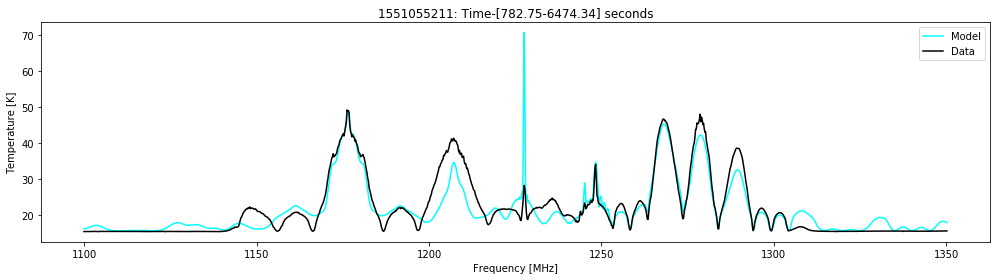

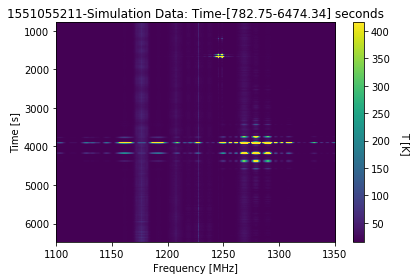

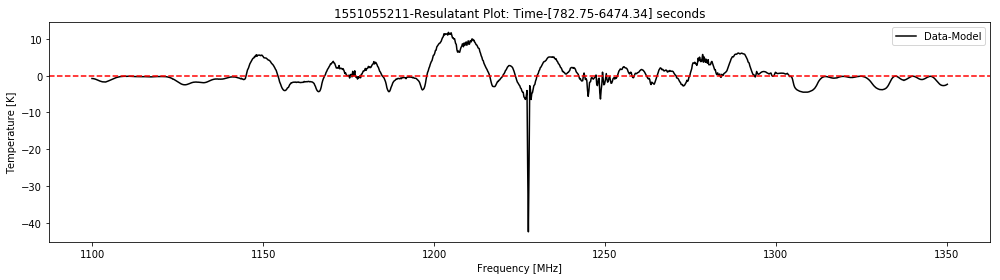

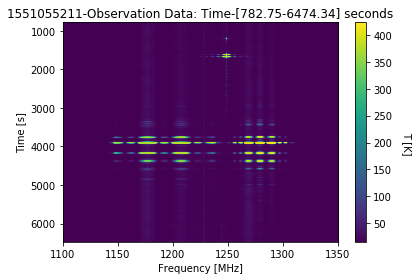

In [42]:
# sat_sims.plotting(individual=1, logger=1, axis_limit=[1270, 1320, 10, 75], tod_limit=None, save_file=None, file_type='pdf')
sat_sims.plotting(individual=None, logger=1, axis_limit=[None, None, None, None], tod_limit=None, save_file=None, file_type='pdf')


### Setting up chi_square

Attempt 1: using the formulalism below

$\chi^{2}$ = $\Sigma \dfrac{(O_i - E_i)^2}{E_i^2}$

In [24]:
chi2_var = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_catalogue_name='table3B_satellite_v3.csv', sat_catalogue_loc='Satellite_Catalogue/', 
            sat_beam='beam_E', frequency_range=[fs,fe])


In [25]:
chi2_var.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
        file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0], threshold=400,                
        add_sub=['Add', 'Sub'], band_lvl=[25, 1])

In [26]:
data = chi2_var.calibration_data_slice

In [28]:
data.shape

(1199, 2201)

In [ ]:
plt.imshow(data.T, aspect='auto')

In [ ]:
# chi2_var.get_simulation_slice(file_bias_choice=[0.3, 0.6, 0.6, 0.5, 0.4, 0.3, 0])[1]

# chi2_var.calibration_data_slice

In [ ]:
def chisq_func((gps, glo, gal, bei, irns, sbas, noise)):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    simulation = chi2_var.get_simulation_slice(file_bias_choice=[gps, glo, gal, bei, irns, sbas, noise])[1]
    data = chi2_var.calibration_data_slice
    
    chi_sq = np.sum((np.log10(simulation) - np.log10(data))**2 / np.log10(data)**2)
    return chi_sq

In [ ]:
choice = np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0])


In [ ]:
s_time = time.time()
chi2 = chisq_func(choice)
print time.time() - s_time

### Using scipy.optimize.minimize

In [ ]:
import scipy.optimize as opt

In [ ]:
result_NM = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Nelder-Mead',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=None,
                      options={'maxiter':1e6,
                              'xatol':1e-5,
                              'fatol':1e-5})

In [ ]:
result_PL = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Powell',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'maxiter':1e6,
                              'xtol':0.0001,
                              'ftol':0.0001})

In [ ]:
result_TNC = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='TNC',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'xtol':1,
                              'ftol':1,
                              'gtol':1})

In [ ]:
print result_NM.x
print '\n'
print result_PL.x
print '\n'
print result_TNC.x

In [ ]:
chi2_test = ss(file_name=fname, sats_only=None, data_loc=data_mkat,sat_loc='../../Outputs/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Plots/chi2/',
            sat_catalogue_name='table3B_satellite_v3.csv', sat_catalogue_loc='Satellite_Catalogue/', 
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



In [ ]:
chi2_test.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
        file_bias_choice=list(result_NM.x),  # 2000-2100sec                
        add_sub=['Add', 'Sub'], band_lvl=[25, 0])

In [ ]:
chi2_test.plotting(individual=None, logger=None, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')
